In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
# 1. Unpack the Training Dataset File
with h5py.File('datasets/train_catvnoncat.h5', "r") as train_h5:
    train_set_x_orig = np.array(train_h5["train_set_x"][:]) 
    train_set_y = np.array(train_h5["train_set_y"][:]).reshape((1, -1)) 

# 2. Unpack the Testing Dataset File
with h5py.File('datasets/test_catvnoncat.h5', "r") as test_h5:
    test_set_x_orig = np.array(test_h5["test_set_x"][:]) 
    test_set_y = np.array(test_h5["test_set_y"][:]).reshape((1, -1)) 
    classes = np.array(test_h5["list_classes"][:])


In [3]:
print(f"(m_train): {train_set_x_orig.shape[0]}")
print(f"(m_test): {test_set_x_orig.shape[0]}")


(m_train): 209
(m_test): 50


In [4]:
plt.clf() 
plt.close('all')

y = [1], it's a 'cat' picture.


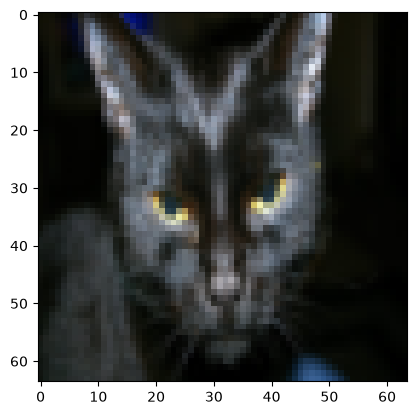

In [5]:


index = 25
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

In [6]:

m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig[0].shape[0]


print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


In [7]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0],-1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0],-1).T

In [8]:
print(train_set_x_flatten.shape)
print(test_set_x_flatten.shape)

(12288, 209)
(12288, 50)


In [9]:
#STANDARDIZE

train_set_x = train_set_x_flatten/255.
test_set_x = test_set_x_flatten/255.

In [10]:
#SIGMOID FUNC


def sigmoid(z):
    s = 1/(1+ np.exp(-z))
    return s


In [11]:
print(sigmoid(np.array([0,2])))

[0.5        0.88079708]


In [12]:
# Initializing parameters W/B

def initialize_with_zeros(dim):
    w = np.zeros([dim,1])
    b = 0
    return w,b

In [13]:
dim = 3
w, b = initialize_with_zeros(dim)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0.]
 [0.]
 [0.]]
b = 0


In [14]:
# Forward and Backward propagation

def propagate(w,b,X,Y):
    m = X.shape[1]
    
#FORWARD PROP

    A = sigmoid(((np.dot(w.T,X)+b)))
    J = - np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A) ) / m

#BACKWARD PROP
    
    dz = A - Y
    dw = np.dot(X,dz.T)/m
    db = np.sum(dz)/m

    grads = {'dw': dw,"db": db}
    J = np.squeeze(J)
    
    return grads,J


In [15]:
w, b, X, Y = np.array([[1],[2]]), 2, np.array([[1,2],[3,4]]), np.array([[1,0]])
grads, cost = propagate(w, b, X, Y)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[0.99993216]
 [1.99980262]]
db = 0.49993523062470574
cost = 6.000064773192205


In [16]:
#Optimization

def optimize(w,b,X,Y,num_iterations,learning_rate,print_cost=False):
    costs = []
    for i in range(num_iterations):
        grads,cost = propagate(w,b,X,Y)
        dw = grads['dw']
        db = grads['db']
        w = w - learning_rate * dw
        b = b - learning_rate * db
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"cost after iteration {i}: {cost}")
    params = {'w':w, 'b':b}
    grads = {'dw': dw,'db': db}
    return params, grads,costs



In [17]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))

w = [[0.1124579 ]
 [0.23106775]]
b = 1.5593049248448891
dw = [[0.90158428]
 [1.76250842]]
db = 0.4304620716786828


In [18]:
# PREDICT

def predict(w,b,X):
    m = X.shape[1]
    Y_prediction = np.zeros((1,m))
    A = sigmoid((np.dot(w.T,X))+b)
    Y_prediction = (A>0.5).astype(int)
    return Y_prediction

In [19]:
print ("predictions = " + str(predict(w, b, X)))

predictions = [[1 1]]


In [20]:
# MODEL

def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.005, print_cost=False):
    #ZEROS INTITIALIZE
    w, b = initialize_with_zeros(X_train.shape[0])
    # GRADIENT DESC
    parameters, grads,costs =optimize(w,b,X_train,Y_train,num_iterations,learning_rate,print_cost)
    
    w = parameters['w']
    b = parameters['b']
    
    # PREDICT 
    Y_prediction_train = predict(w,b,X_train)
    Y_prediction_test = predict(w,b,X_test)

    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d



In [21]:
d = model(train_set_x,train_set_y,test_set_x, test_set_y,num_iterations= 2000,learning_rate=0.005,print_cost=True)

cost after iteration 0: 0.6931471805599453
cost after iteration 100: 0.5845083636993086
cost after iteration 200: 0.46694904094655476
cost after iteration 300: 0.37600686694802077
cost after iteration 400: 0.33146328932825125
cost after iteration 500: 0.30327306747438293
cost after iteration 600: 0.27987958658260487
cost after iteration 700: 0.2600421369258757
cost after iteration 800: 0.2429406846779662
cost after iteration 900: 0.2280042225672607
cost after iteration 1000: 0.2148195137844964
cost after iteration 1100: 0.2030781906064499
cost after iteration 1200: 0.1925442771670686
cost after iteration 1300: 0.18303333796883506
cost after iteration 1400: 0.17439859438448882
cost after iteration 1500: 0.16652139705400335
cost after iteration 1600: 0.15930451829756614
cost after iteration 1700: 0.15266732471296504
cost after iteration 1800: 0.14654223503982342
cost after iteration 1900: 0.1408720757031016
train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


y = 1, you predicted that it is a "cat" picture.


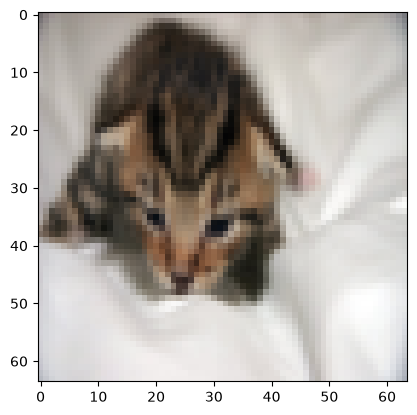

In [28]:
index = 1
plt.imshow(test_set_x[:,index].reshape((num_px, num_px, 3)))
print ("y = " + str(test_set_y[0,index]) + ", you predicted that it is a \"" + classes[d["Y_prediction_test"][0,index]].decode("utf-8") +  "\" picture.")

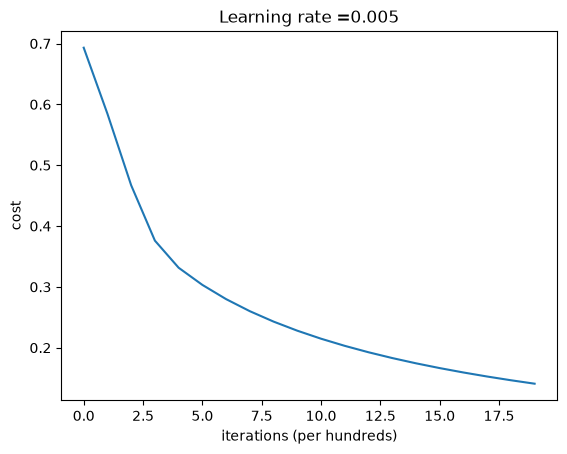

In [29]:
# Plot learning curve (with costs)
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(d["learning_rate"]))
plt.show()